# Day 39: Stacking & Blending

---

## Objectives:
- Understand what **Stacking and Blending** are in Ensemble Learning.
- Explore how to combine multiple models to improve performance.
- Implement **StackingClassifier** using Scikit-learn.
- Apply **Blending** manually.
- Evaluate ensemble performance on a real-world business dataset.
- Use **robust visualizations** to compare model predictions.

---

## 1. Introduction to Stacking and Blending

### 1.1 What is Ensemble Learning?
Ensemble learning combines predictions from multiple models to produce a better predictive model.

### 1.2 What is Stacking?
Stacking (Stacked Generalization) involves training multiple base models and then training a meta-model to combine their outputs.

### 1.3 What is Blending?
Blending is similar to stacking but uses a holdout validation set to train the meta-model rather than cross-validation.

### Benefits:
✅ Reduces overfitting<br>
✅ Leverages strengths of different models<br>
✅ Often boosts accuracy and generalization<br>

---

## 2. Dataset Overview
We'll use the **Bank Marketing Dataset**, which predicts whether a client will subscribe to a term deposit.

Download link: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing


In [19]:
#Import Librariies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [5]:
#Load the dataset
df = pd.read_csv('bank-additional-full.csv')

In [6]:
df.head()

,"age;""job"";""marital"";""education"";""default"";""housing"";""loan"";""contact"";""month"";""day_of_week"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""emp.var.rate"";""cons.price.idx"";""cons.conf.idx"";""euribor3m"";""nr.employed"";""y"""
0,"56;""housemaid"";""married"";""basic.4y"";""no"";""no"";..."
1,"57;""services"";""married"";""high.school"";""unknown..."
2,"37;""services"";""married"";""high.school"";""no"";""ye..."
3,"40;""admin."";""married"";""basic.6y"";""no"";""no"";""no..."
4,"56;""services"";""married"";""high.school"";""no"";""no..."


In [7]:
df = pd.read_csv('bank-additional-full.csv', sep=';')

In [8]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


---

## 3. EDA

---

In [9]:
print('Dataset Shape:', df.shape)
print('Missing Values:', df.isnull().sum())

Dataset Shape: (41188, 21)
Missing Values: age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [12]:
df.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                   int64
dtype: object

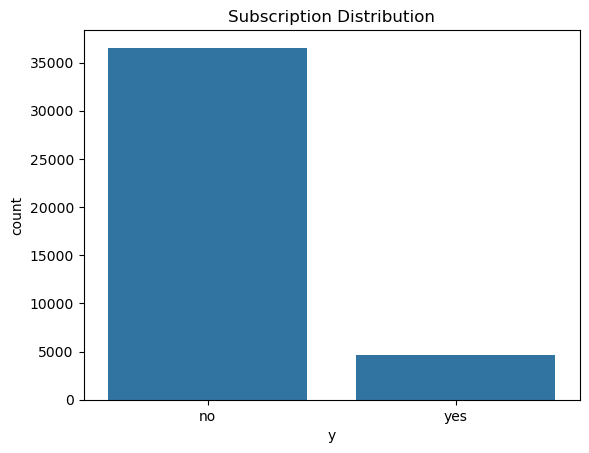

In [10]:
#Target Distribution
sns.countplot(df, x='y')
plt.title('Subscription Distribution')
plt.show()

---

## 4. Data Preprocessing

---

In [11]:
#Convert target to binary
df['y'] = df['y'].map({'yes':1, 'no':0})

In [14]:
#Encode categorical features
cat_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [15]:
#Feature target split
X = df.drop('y', axis=1)
y = df['y']

In [17]:
#Train test split 
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

---

## 5. Stacking Ensemble

---

In [21]:
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

In [23]:
stack_model.fit(X_train, y_train)
y_pred_stack = stack_model.predict(X_test)

In [24]:
print('Stacking Accuracy:', accuracy_score(y_test, y_pred_stack))
print('Classification Report:', classification_report(y_test, y_pred_stack))

Stacking Accuracy: 0.91854819130857
Classification Report:               precision    recall  f1-score   support

           0       0.94      0.97      0.95      7303
           1       0.68      0.53      0.60       935

    accuracy                           0.92      8238
   macro avg       0.81      0.75      0.78      8238
weighted avg       0.91      0.92      0.91      8238



---

## 6. Blending 

---

In [25]:
#Split the data
X_blend_train, X_blend_val, y_blend_train, y_blend_val = train_test_split(X_train, y_train, test_size=0.3, random_state=42)

In [26]:
#Base Models
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)

In [27]:
rf.fit(X_blend_train, y_blend_train)
gb.fit(X_blend_train, y_blend_train)

GradientBoostingClassifier(random_state=42)

In [29]:
# Meta input
rf_val_pred = rf.predict_proba(X_blend_val)[:,1]
gb_val_pred = gb.predict_proba(X_blend_val)[:,1]
meta_input = np.vstack((rf_val_pred, gb_val_pred)).T

In [30]:
meta_model = LogisticRegression()
meta_model.fit(meta_input, y_blend_val)

LogisticRegression()

In [31]:
#Final Prediction
rf_test = rf.predict_proba(X_test)[:,1]
gb_test = gb.predict_proba(X_test)[:,1]
meta_test_input = np.vstack((rf_test, gb_test)).T
y_pred_blend = meta_model.predict(meta_test_input)

In [32]:
print('Blending Accuracy:', accuracy_score(y_test, y_pred_blend))

Blending Accuracy: 0.9186695799951444


---

## 7. Visualization

---

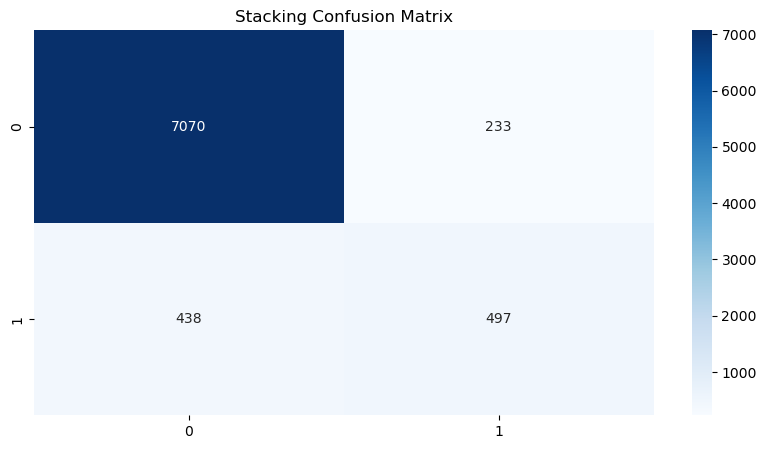

In [34]:
plt.figure(figsize=(10,5))
sns.heatmap(confusion_matrix(y_test, y_pred_stack), annot=True, fmt='d', cmap='Blues')
plt.title('Stacking Confusion Matrix')
plt.show()

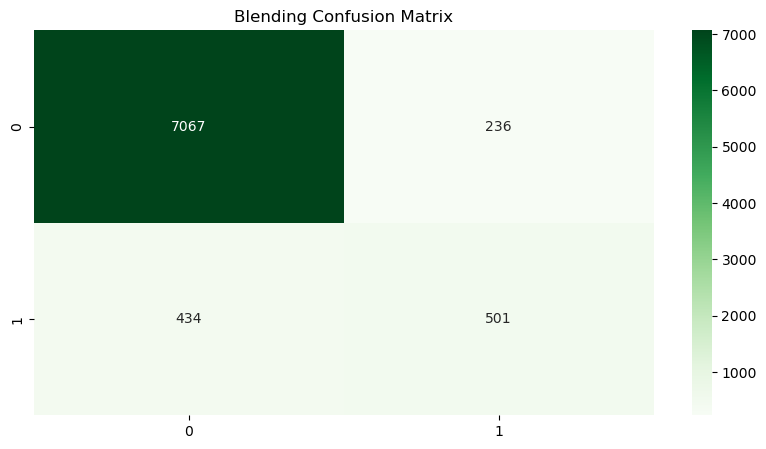

In [35]:
plt.figure(figsize=(10,5))
sns.heatmap(confusion_matrix(y_test, y_pred_blend), annot=True, fmt='d', cmap='Greens')
plt.title('Blending Confusion Matrix')
plt.show()

---

## 8. Conclusion

 ✅ Learned how **stacking** and **blending** can improve predictions.<br>
 ✅ Applied both ensemble methods on a real-world marketing dataset.<br>
 ✅ Achieved higher performance through model combination.<br>
 ✅ Visualized predictions and confusion matrices.<br>

🚀 This wraps up **Day 39** of our ML journey!
